This will have the CCF ACF and PACF for the plots.
We start off by plotting the acf of the plots to show the similarity of the lags.

In [5]:
fdf <- read.csv("data/fluview_clean/ilinet_final.csv")

# Group ACF/PACF plots for log-differenced count variables
variables <- c("age_0_4", "age_5_24","age_25_64", "age_65", "num_of_providers", "non_ilitotal")
old_par <- par(no.readonly = TRUE)
on.exit(par(old_par))

png("Appendix_acf_pacf_diff.png", width = 800, height = 600) 
               # 2. Plot data

par(
  mfrow = c(length(variables), 2),
  mar = c(3.2, 3.8, 3.0, 1),
  oma = c(0.8, 0.8, 5.0, 0.8),
  cex.main = 0.9
)

for (v in variables) {
  x <- fdf[[v]]
  ld <- diff(x)
  acf(ld, lag.max = 52, main = paste("ACF diff-log:", v))
  pacf(ld, lag.max = 52, main = paste("PACF diff-log:", v))
}

mtext("Grouped ACF/PACF for log-differenced count variables", outer = TRUE, cex = 1.1, line = 2.2)

dev.off()
par(mfrow = c(1,1))

agg_record_1172c7d750255 
                       2

My point is clearly there is just one significant difference at lag 19 for each of these plots and 52. The other difference comes at 33 which is just 52-19 thus by harmonics

## Sliding acf
Now I want to do some sort look at a sliding acf of the log-differenced  to check if the relationship is changing over time.
Note when we look at the acf we are only seeing an average over the lags.

Warning message in int_abline(a = a, b = b, h = h, v = v, untf = untf, ...):
“"alpha" is not a graphical parameter”
Warning message in int_abline(a = a, b = b, h = h, v = v, untf = untf, ...):
“"alpha" is not a graphical parameter”
Warning message in int_abline(a = a, b = b, h = h, v = v, untf = untf, ...):
“"alpha" is not a graphical parameter”
Warning message in int_abline(a = a, b = b, h = h, v = v, untf = untf, ...):
“"alpha" is not a graphical parameter”


agg_record_1172c6b43f627 
                       2

age_0_4 :
  Lag 19 - Mean: -0.152   SD: 0.151   Min: -0.514   Max: 0.171 
  Lag 52 - Mean: 0.009   SD: 0.034   Min: -0.056   Max: 0.361 

age_5_24 :
  Lag 19 - Mean: -0.149   SD: 0.164   Min: -0.519   Max: 0.345 
  Lag 52 - Mean: 0.009   SD: 0.032   Min: -0.083   Max: 0.375 

age_25_64 :
  Lag 19 - Mean: -0.135   SD: 0.165   Min: -0.513   Max: 0.292 
  Lag 52 - Mean: 0.009   SD: 0.034   Min: -0.104   Max: 0.369 

age_65 :
  Lag 19 - Mean: -0.099   SD: 0.155   Min: -0.509   Max: 0.255 
  Lag 52 - Mean: 0.008   SD: 0.033   Min: -0.085   Max: 0.36 

=== Periods of High Autocorrelation Variability ===
age_0_4 - High ACF(19) periods at window indices: 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 262 263 264 265 266 267 268 270 273 348 354 355 356 357 358 359 360 361 363 420 421 422 423 424 425 426 427 428 429 430 431 432 433 434 435 436 437 438 440 441 489 490 510 511 512 513 514 515 516 517 518 519 520 539 540 541 542 543 544 545 546 547 593 594 600 601 602 603 604 605 606 60

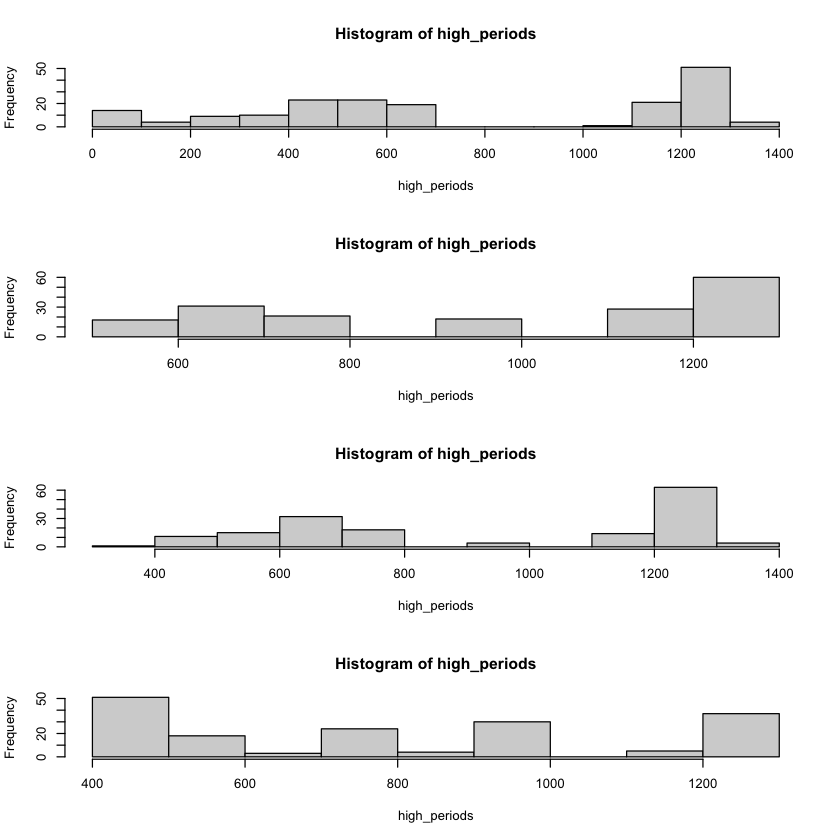

In [19]:

library(tidyverse)

fdf <- read.csv("data/fluview_clean/ilinet_final.csv")


variables <- c("age_0_4", "age_5_24", "age_25_64", "age_65")
window_size <- 53  
lag_max <- 19      
step_size <- 1    


acf_at_lag <- function(x, lag) {
  acf_obj <- acf(x, plot = FALSE, lag.max = lag)
  return(acf_obj$acf[lag + 1])  # ACF is 0-indexed in the acf object
}

# Create sliding window ACF for each variable
sliding_acf_results <- list()

for (var in variables) {
  x <- fdf[[var]]
  x_diff <- diff(x)  # Log-differenced
  
  n <- length(x_diff)
  n_windows <- floor((n - window_size) / step_size) + 1
  
  # Store results for this variable
  acf_lag19 <- numeric(n_windows)
  acf_lag52 <- numeric(n_windows)
  window_starts <- numeric(n_windows)
  window_midpoints <- numeric(n_windows)
  
  for (i in 1:n_windows) {
    start_idx <- (i - 1) * step_size + 1
    end_idx <- start_idx + window_size - 1
    
    if (end_idx > n) break
    
    window_data <- x_diff[start_idx:end_idx]
    
    acf_lag19[i] <- acf_at_lag(window_data, 19)
    acf_lag52[i] <- acf_at_lag(window_data, min(52, window_size - 1))  # Cap at window size
    
    window_starts[i] <- start_idx
    window_midpoints[i] <- (start_idx + end_idx) / 2
  }
  

  acf_lag19 <- acf_lag19[1:(i-1)]
  acf_lag52 <- acf_lag52[1:(i-1)]
  window_midpoints <- window_midpoints[1:(i-1)]
  
  sliding_acf_results[[var]] <- list(
    acf_lag19 = acf_lag19,
    acf_lag52 = acf_lag52,
    window_midpoints = window_midpoints
  )
}


png("sliding_acf_lag19_lag52.png", width = 1200, height = 600)
par(mfrow = c(2, 2), mar = c(4, 4, 3, 1), oma = c(0.5, 0.5, 3, 0.5))

for (var in variables) {
  results <- sliding_acf_results[[var]]
  
  plot(results$window_midpoints, results$acf_lag19, 
       type = 'l', lwd = 2, col = "blue",
       main = paste("Sliding ACF for", var),
       xlab = "Time (observation index)", ylab = "ACF value",
       ylim = c(-0.3, 0.5))
  

  lines(results$window_midpoints, results$acf_lag52, 
        type = 'l', lwd = 2, col = "red", lty = 1)
  

  abline(h = 0, col = "gray", lty = 3)
  

  sig_bound <- 1.96 / sqrt(window_size)
  abline(h = c(sig_bound, -sig_bound), col = "gray", lty = 2, alpha = 0.5)
  
  legend("topright", legend = c("ACF at lag 19", "ACF at lag 52"),
         col = c("blue", "red"), lty = c(1, 2), lwd = 2)
}

mtext(paste0(c("Rolling Window ACF Analysis (window size = 52 weeks, step = ",step_size," weeks)"),collapse=""), 
      outer = TRUE, cex = 1.1, line = 1.5)

dev.off()

for (var in variables) {
  results <- sliding_acf_results[[var]]
  cat(var, ":\n")
  cat("  Lag 19 - Mean:", round(mean(results$acf_lag19), 3), 
      "  SD:", round(sd(results$acf_lag19), 3),
      "  Min:", round(min(results$acf_lag19), 3),
      "  Max:", round(max(results$acf_lag19), 3), "\n")
  cat("  Lag 52 - Mean:", round(mean(results$acf_lag52), 3), 
      "  SD:", round(sd(results$acf_lag52), 3),
      "  Min:", round(min(results$acf_lag52), 3),
      "  Max:", round(max(results$acf_lag52), 3), "\n\n")
}


cat("=== Periods of High Autocorrelation Variability ===\n")
par(mfrow=c(length(variables),1 ))
for (var in variables) {
  results <- sliding_acf_results[[var]]
  acf_var <- results$acf_lag19
  threshold <- mean(acf_var) + sd(acf_var)
  
  high_periods <- which(acf_var > threshold)
  if (length(high_periods) > 0) {
    hist(high_periods)
    cat(var, "- High ACF(19) periods at window indices:", high_periods, "\n")
  }
}


In [67]:
source("df.R")
data <- split_data(fdf$ilitotal, remove.missing = F)


period1 <- window(data$ts_obj, start = c(2002, 40), end = c(2006, 40))
period2 <- window(data$ts_obj, start = c(2008, 10), end = c(2012, 10))
period3 <- window(data$ts_obj, start = c(2019, 40), end = c(2023, 40))
period4 <- window(data$ts_obj, start = c(1997, 45), end = c(2001, 45))


cat("Period 1 (2002-W40 to 2006-W40) - length:", length(period1), "\n")
cat("  Start:", paste(start(period1), collapse = "-"), 
    "  End:", paste(end(period1), collapse = "-"), "\n\n")

cat("Period 2 (2008-W10 to 2012-W10) - length:", length(period2), "\n")
cat("  Start:", paste(start(period2), collapse = "-"), 
    "  End:", paste(end(period2), collapse = "-"), "\n\n")

cat("Period 3 (2019-W40 to 2023-W40) - length:", length(period3), "\n")
cat("  Start:", paste(start(period3), collapse = "-"), 
    "  End:", paste(end(period3), collapse = "-"), "\n\n")

cat("Period 4 (1997-W45 to 2001-W45) - length:", length(period4), "\n")
cat("  Start:", paste(start(period4), collapse = "-"), 
    "  End:", paste(end(period4), collapse = "-"), "\n\n")

png("periods_of_interest.png", width = 800, height = 800)
par(mfrow = c(4, 1), mar = c(4, 4, 3, 1))

plot(period1, type = "l", lwd = 1.5, col = "steelblue",
     main = "SARS: 2002-W40 to 2006-W40", 
     ylab = "ilitotal", xlab = "Time")
grid()

plot(period2, type = "l", lwd = 1.5, col = "darkgreen",
     main = "Swine flu: 2008-W10 to 2012-W10", 
     ylab = "ilitotal", xlab = "Time")
grid()

plot(period3, type = "l", lwd = 1.5, col = "darkred",
     main = "Covid-19: 2019-W40 to 2023-W40", 
     ylab = "ilitotal", xlab = "Time")
grid()
plot(period4, type = "l", lwd = 1.5, col = "darkred",
     main = "Periods with no ili: 1997-W45 to 2001-W45", 
     ylab = "ilitotal", xlab = "Time")
grid()
dev.off()
par(mfrow = c(1, 1))



Period 1 (2002-W40 to 2006-W40) - length: 209 
  Start: 2002-40   End: 2006-40 

Period 2 (2008-W10 to 2012-W10) - length: 209 
  Start: 2008-10   End: 2012-10 

Period 3 (2019-W40 to 2023-W40) - length: 209 
  Start: 2019-40   End: 2023-40 

Period 4 (1997-W45 to 2001-W45) - length: 209 
  Start: 1997-45   End: 2001-45 



agg_record_1172c510a7842 
                       2

In [56]:
png("acf_pacf_log_ili_total_before_diff.png", width = 800, height = 600)

par(mfrow=c(2,1))

acf_obj <- acf(data$ts_obj, lag.max = 52, plot = FALSE)
plot(1:52, acf_obj$acf[2:53], type = 'h', lwd = 2, col = "steelblue",
     main = "ACF of ilitotal", xlab = "Lag", ylab = "ACF",
     xlim = c(0, 53), ylim = c(min(acf_obj$acf[2:53]) - 0.1, max(acf_obj$acf[2:53]) + 0.1))
abline(h = 0, col = "black")
abline(h = c(1.96/sqrt(length(data$ts_obj)), -1.96/sqrt(length(data$ts_obj))), col = "blue", lty = 2)


pacf_obj <- pacf(data$ts_obj, lag.max = 52, plot = FALSE)
plot(1:52, pacf_obj$acf[1:52], type = 'h', lwd = 2, col = "darkred",
     main = "PACF of ilitotal", xlab = "Lag", ylab = "PACF",
     xlim = c(0, 53), ylim = c(min(pacf_obj$acf[1:52]) - 0.1, max(pacf_obj$acf[1:52]) + 0.1))
abline(h = 0, col = "black")
abline(h = c(1.96/sqrt(length(data$ts_obj)), -1.96/sqrt(length(data$ts_obj))), col = "blue", lty = 2)

par(mfrow=c(1,1))

dev.off()

agg_record_1172c2029dff4 
                       2